<a href="https://colab.research.google.com/github/shyamsundarsah123/machine-learning/blob/main/ML_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lab 3 Session Data.xlsx to Lab 3 Session Data.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("Lab 3 Session Data.xlsx",sheet_name ="marketing_campaign")

In [ ]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [ ]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [ ]:
#A2
def label_encoding(data, columns):
    data = data.copy()

    encoder = LabelEncoder()

    for col in columns:
        data[col] = encoder.fit_transform(data[col].astype(str))

    return data

def one_hot_encoding(data, columns):
    data = data.copy()

    data = pd.get_dummies(data,
                          columns=columns,
                          drop_first=False)

    return data

In [ ]:
#A3
print(df["Education"].unique())
print(df["Marital_Status"].unique())

categorical_cols = ["Education", "Marital_Status"]

# Label Encoding
label_df = label_encoding(df, categorical_cols)

# One Hot Encoding
onehot_df = one_hot_encoding(df, categorical_cols)

print("Original Shape :", df.shape)
print("Label Encoded Shape :", label_df.shape)
print("One Hot Shape :", onehot_df.shape)

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
Original Shape : (2240, 29)
Label Encoded Shape : (2240, 29)
One Hot Shape : (2240, 40)


In [ ]:
print(label_df[["Education", "Marital_Status"]].head())

   Education  Marital_Status
0          2               4
1          2               4
2          2               5
3          2               5
4          4               3


In [ ]:
print(onehot_df.filter(regex="Education|Marital_Status").head())

   Education_2n Cycle  Education_Basic  Education_Graduation  \
0               False            False                  True   
1               False            False                  True   
2               False            False                  True   
3               False            False                  True   
4               False            False                 False   

   Education_Master  Education_PhD  Marital_Status_Absurd  \
0             False          False                  False   
1             False          False                  False   
2             False          False                  False   
3             False          False                  False   
4             False           True                  False   

   Marital_Status_Alone  Marital_Status_Divorced  Marital_Status_Married  \
0                 False                    False                   False   
1                 False                    False                   False   
2                 Fa

In [ ]:
#A4
def minkowski_distance(x, y, p):
    total = 0
    for i in range(len(x)):
        total += abs(x[i] - y[i]) ** p
    return total ** (1 / p)

A = [2, 3]
B = [5, 7]

print(minkowski_distance(A, B, 3))

4.497941445275415


[5.5240e+03 1.9570e+03 2.0000e+00 4.0000e+00 5.8138e+04 0.0000e+00
 0.0000e+00 5.8000e+01 6.3500e+02 8.8000e+01 5.4600e+02 1.7200e+02
 8.8000e+01 8.8000e+01 3.0000e+00 8.0000e+00 1.0000e+01 4.0000e+00
 7.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 3.0000e+00 1.1000e+01 1.0000e+00]
[2.1740e+03 1.9540e+03 2.0000e+00 4.0000e+00 4.6344e+04 1.0000e+00
 1.0000e+00 3.8000e+01 1.1000e+01 1.0000e+00 6.0000e+00 2.0000e+00
 1.0000e+00 6.0000e+00 2.0000e+00 1.0000e+00 1.0000e+00 2.0000e+00
 5.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 3.0000e+00 1.1000e+01 0.0000e+00]
p	Distance
1	16781.0000
2	12290.3712
3	11884.3746
4	11813.1821
5	11798.3595
6	11795.0321
7	11794.2513
8	11794.0625
9	11794.0158
10	11794.0040


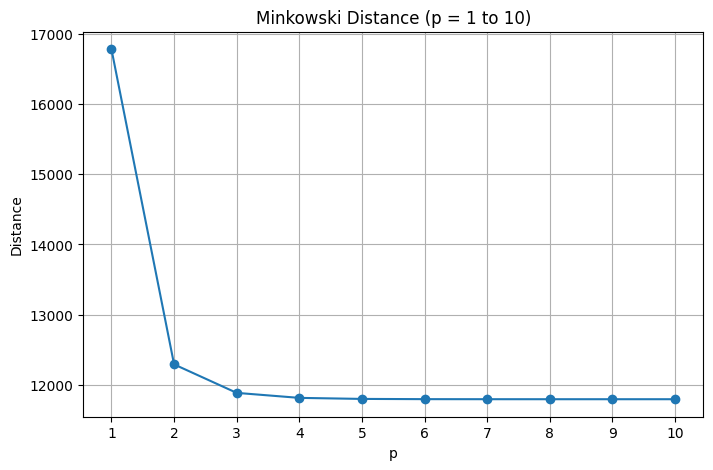

In [ ]:
#A5

import matplotlib.pyplot as plt

def minkowski_distance(x, y, p):
    total = 0
    for i in range(len(x)):
        total += abs(x[i] - y[i]) ** p
    return total ** (1 / p)

# Use the label encoded dataset (numeric values)
numeric_df = label_df.select_dtypes(include=['number'])

# Take any two feature vectors
A = numeric_df.iloc[0].values
B = numeric_df.iloc[1].values

p_values = []
distances = []

for p in range(1, 11):
    p_values.append(p)
    distances.append(minkowski_distance(A, B, p))

print("p\tDistance")
for p, d in zip(p_values, distances):
    print(f"{p}\t{d:.4f}")

plt.figure(figsize=(8,5))
plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance (p = 1 to 10)")
plt.xlabel("p")
plt.ylabel("Distance")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
#A6
from scipy.spatial.distance import minkowski
package_distance = minkowski(A,B,2)
print(package_distance)
my_distance = minkowski_distance(A,B,2)
print(my_distance)
difference = abs(package_distance - my_distance)
print(difference)

12290.371231171172
12290.371231171172
0.0


In [ ]:
#A7
def dot_product(A,B):
  result = 0
  for i in range(len(A)):
    result += A[i]*B[i]
  return result

def euclidean_norm(A):
  total = 0
  for i in range(len(A)):
    total += A[i]**2
  return total**0.5

my_dot = dot_product(A, B)
my_norm_A = euclidean_norm(A)
my_norm_B = euclidean_norm(B)


numpy_dot = np.dot(A,B)
numpy_norm_A = np.linalg.norm(A)
numpy_norm_B = np.linalg.norm(B)

print("Dot Product")
print("My Function :", my_dot)
print("NumPy       :", numpy_dot)

print("\nEuclidean Norm of A")
print("My Function :", my_norm_A)
print("NumPy       :", numpy_norm_A)

print("\nEuclidean Norm of B")
print("My Function :", my_norm_B)
print("NumPy       :", numpy_norm_B)

Dot Product
My Function : 2710194356.0
NumPy       : 2710194356.0

Euclidean Norm of A
My Function : 58439.108300863045
NumPy       : 58439.108300863045

Euclidean Norm of B
My Function : 46436.11264953172
NumPy       : 46436.11264953172


In [ ]:
#A8
def mean(data):
  total = 0
  for value in data:
    total += value
  return total/len(data)

def variance(data):
  mean_value = mean(data)
  total = 0
  for value in data:
    total += (value - mean_value)**2
  return total/len(data)

def std(data):
  variance_value = variance(data)
  return variance_value**0.5

def dataset_statistics(dataframe):
    numeric_df = dataframe.select_dtypes(include=['number'])

    for column in numeric_df.columns:
        values = numeric_df[column].tolist()

        my_mean = mean(values)
        my_variance = variance(values)
        my_std = std(values)

        print("Feature :", column)
        print("Mean :", my_mean)
        print("Variance :", my_variance)
        print("Standard Deviation :", my_std)
        print("-" * 40)

dataset_statistics(label_df)

Feature : ID
Mean : 5592.159821428571
Variance : 10536109.703921402
Standard Deviation : 3245.9374152810465
----------------------------------------
Feature : Year_Birth
Mean : 1968.8058035714287
Variance : 143.5538056042729
Standard Deviation : 11.98139414276456
----------------------------------------
Feature : Education
Mean : 2.39375
Variance : 1.2646037946428264
Standard Deviation : 1.12454603936114
----------------------------------------
Feature : Marital_Status
Mean : 3.7299107142857144
Variance : 1.1578553491709107
Standard Deviation : 1.0760368716595685
----------------------------------------
Feature : Income
Mean : nan
Variance : nan
Standard Deviation : nan
----------------------------------------
Feature : Kidhome
Mean : 0.44419642857142855
Variance : 0.28974310427295247
Standard Deviation : 0.5382779061720372
----------------------------------------
Feature : Teenhome
Mean : 0.50625
Variance : 0.296389508928571
Standard Deviation : 0.5444166684889167
--------------------

In [ ]:
#A9

numeric_df = label_df.select_dtypes(include=['number'])

for column in numeric_df.columns:
    values = numeric_df[column].values

    my_mean = mean(values)
    my_std = std(values)

    numpy_mean = np.mean(values)
    numpy_std = np.std(values)

    print("Feature :", column)
    print("My Mean :", my_mean)
    print("NumPy Mean :", numpy_mean)

    print("My Standard Deviation :", my_std)
    print("NumPy Standard Deviation :", numpy_std)

    print("-" * 50)

Feature : ID
My Mean : 5592.159821428571
NumPy Mean : 5592.159821428571
My Standard Deviation : 3245.9374152810465
NumPy Standard Deviation : 3245.9374152810456
--------------------------------------------------
Feature : Year_Birth
My Mean : 1968.8058035714287
NumPy Mean : 1968.8058035714287
My Standard Deviation : 11.98139414276456
NumPy Standard Deviation : 11.981394142764563
--------------------------------------------------
Feature : Education
My Mean : 2.39375
NumPy Mean : 2.39375
My Standard Deviation : 1.12454603936114
NumPy Standard Deviation : 1.1245460393611535
--------------------------------------------------
Feature : Marital_Status
My Mean : 3.7299107142857144
NumPy Mean : 3.7299107142857144
My Standard Deviation : 1.0760368716595685
NumPy Standard Deviation : 1.076036871659572
--------------------------------------------------
Feature : Income
My Mean : nan
NumPy Mean : nan
My Standard Deviation : nan
NumPy Standard Deviation : nan
--------------------------------------

Histogram Counts:
[1654  554    7    0    0    0    0    0    0    1]

Bin Edges:
[  1730.   68223.6 134717.2 201210.8 267704.4 334198.  400691.6 467185.2
 533678.8 600172.4 666666. ]

Mean : 52247.25135379061
Variance : 633397830.1872728


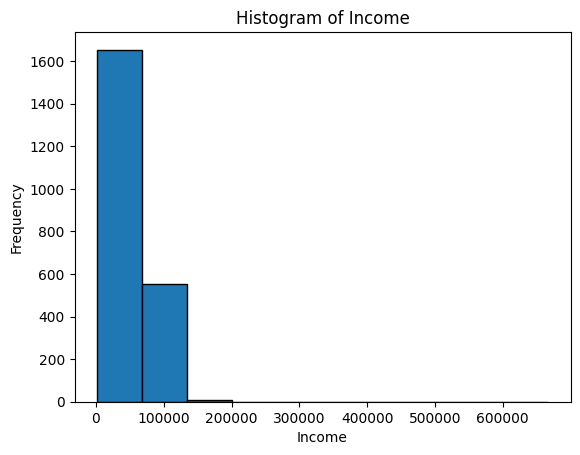

In [ ]:
#A10

feature = label_df["Income"].dropna()

hist, bins = np.histogram(feature, bins=10)

print("Histogram Counts:")
print(hist)

print("\nBin Edges:")
print(bins)

mean_value = np.mean(feature)
variance_value = np.var(feature)

print("\nMean :", mean_value)
print("Variance :", variance_value)

plt.hist(feature, bins=10, edgecolor='black')
plt.title("Histogram of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#A11
from sklearn.cluster import KMeans

numeric_df = label_df.select_dtypes(include=['number'])

numeric_df = numeric_df.dropna()

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

kmeans.fit(numeric_df)

labels = kmeans.labels_

centroids = kmeans.cluster_centers_

print("Cluster Labels:")
print(labels)

print("\nCluster Centroids:")
print(centroids)

print("\nNumber of Points in Each Cluster:")
for i in range(3):
    print("Cluster", i + 1, ":", (labels == i).sum())

Cluster Labels:
[2 2 1 ... 2 1 2]

Cluster Centroids:
[[ 5.58414815e+03  1.97283871e+03  2.19832736e+00  3.71565114e+00
   2.98794719e+04  7.95698925e-01  3.47670251e-01  4.87718041e+01
   3.90107527e+01  6.44563919e+00  2.79820789e+01  9.52090800e+00
   6.36200717e+00  1.91612903e+01  2.21146953e+00  2.28434886e+00
   5.93787336e-01  3.18996416e+00  6.83632019e+00  8.60215054e-02
   5.97371565e-03  1.01307851e-15  1.19474313e-03 -1.52655666e-16
   1.55316607e-02  3.00000000e+00  1.10000000e+01  1.18279570e-01]
 [ 5.65043058e+03  1.96786643e+03  2.46572935e+00  3.73637961e+00
   8.02561213e+04  7.90861160e-02  2.84710018e-01  4.89420035e+01
   6.36768014e+02  6.05272408e+01  4.32166960e+02  8.75272408e+01
   6.46871705e+01  7.22548330e+01  1.42706503e+00  5.32513181e+00
   5.71177504e+00  8.32161687e+00  2.96485062e+00  7.73286467e-02
   1.37082601e-01  2.68892794e-01  2.12653779e-01  2.81195079e-02
   3.51493849e-03  3.00000000e+00  1.10000000e+01  2.67135325e-01]
 [ 5.54909136e+03  1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

class KMeans:
    def __init__(self, k=3, max_iter=100):
        self.k = k
        self.max_iter = max_iter

    def fit(self, X):
        np.random.seed(42)

        idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[idx]

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[labels == i].mean(axis=0) if np.any(labels == i) else self.centroids[i]
                for i in range(self.k)
            ])

            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

        self.labels_ = labels

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)


df = pd.read_excel("Lab 3 Session Data.xlsx", sheet_name="marketing_campaign")

df.drop("ID", axis=1, inplace=True)

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Customer_Since_Year"] = df["Dt_Customer"].dt.year
df.drop("Dt_Customer", axis=1, inplace=True)

def label_encode(series):
    mapping = {v: i for i, v in enumerate(series.unique())}
    return series.map(mapping)

df["Education"] = label_encode(df["Education"])

df = pd.get_dummies(df, columns=["Marital_Status"])

X = df.values

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

kmeans = KMeans(k=3)
kmeans.fit(X)

print("Centroids:")
print(kmeans.centroids)

print("\nCluster Labels:")
print(kmeans.labels_)

Centroids:
[[-1.08200414e-01 -1.03722032e-01  7.98673701e-01 -6.96266110e-01
  -1.49782551e-01  1.10118951e-02  9.05604457e-01  7.46485164e-01
   8.76418908e-01  7.60364637e-01  7.30104456e-01  6.12811205e-01
  -1.64582340e-01  6.16123596e-01  9.18349509e-01  8.56897354e-01
  -6.72606143e-01  3.69004696e-02  2.26764224e-01  4.21878519e-01
   3.71067252e-01  1.59824780e-01 -1.18263985e-02  0.00000000e+00
   0.00000000e+00  2.18846104e-01 -1.02977479e-01  4.88855866e-02
  -3.66207838e-02  5.00555041e-02  5.17912298e-03  2.25276967e-02
   1.85602572e-02 -1.88676192e-01 -2.98940638e-02]
 [-8.55272925e-01 -4.77845180e-02  1.66957321e-01 -3.90932253e-01
   2.38996423e-01  1.15631156e-03  1.94153619e-01  1.70721815e-01
   9.89773154e-02  2.53844385e-01  2.89548560e-01  2.44351739e-01
   6.55466267e-03  1.93857813e-01  2.26735165e-01  1.92418808e-01
  -1.78640776e-01 -8.01516800e-02  2.10593656e-01  1.19836917e-01
   2.64758805e-03 -3.53061653e-03 -9.72816653e-02  0.00000000e+00
   0.00000000e